In [4]:
import os
import torch
from equiv_dens.training.parse_command_line_arguments import parse_command_line_arguments
from equiv_dens.data.density_dataset import AtomsDensityData
from equiv_dens.utils.grids import cubical_grid, cubical_sampling,\
    spherical_grid, spherical_radial_sampling
import equiv_dens.utils.base as utils
from equiv_dens.training.model_loader import load_model

import numpy as np
from functools import partial
import argparse
import copy
import ase.io
import equiv_dens.utils.cubetools as cubetools

%load_ext autoreload
%autoreload 2

In [5]:
args, hyperparam_args = parse_command_line_arguments(arg_file='water_dyn_spherical_2_test.txt')
print('type dtype', type(args.dtype))
args.fix_arguments = True
print('args np dir', args.np_dataset)
# no restart directory specified
directory = args.restart  # load directory name
# load latest checkpoint
checkpoint_path = os.path.join(directory, 'checkpoints')  # checkpoint directory
checkpoint = torch.load(os.path.join(
    checkpoint_path, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['step']
model_code = checkpoint['ID']  # load ID
step = checkpoint['step']
for arg in vars(checkpoint['args']):
    if args.fix_arguments:
        if arg in hyperparam_args:
            print('loading hyperparam arg', arg)
            setattr(args, arg, getattr(checkpoint['args'], arg))
    else:
        print('loading all arg', arg)
        setattr(args, arg, getattr(checkpoint['args'], arg))
restore = True

args.best_model_path = 'best_' + model_code + '.pth'
print('best_model_path', args.best_model_path)

print('model code:', model_code)
# determine whether GPU is used for training
print('args use gpu', args.use_gpu)
args.use_gpu = args.use_gpu and torch.cuda.is_available()

# load dataset(s)
print("loading density from" + str(args.dens_dataset) + "...")
print("loading atoms from" + args.np_dataset + "...")
args.use_gpu = False
if args.cube_grid:
    grid_origin = args.cube_origin
    grid_extent = np.array([args.cube_extent] * 3)
    grid_fn = partial(cubical_grid, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                      extent=grid_extent,
                      origin=np.array([grid_origin] * 3))
    sampling_fn = cubical_sampling
else:
    grid_fn = partial(spherical_grid, level=2)
    sampling_fn = partial(spherical_radial_sampling, rotate=False)
    grid_origin = 0
    grid_extent = None

dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=args.dtype,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=args.verbose)
torch.manual_seed(0)
np.random.seed(0)
args.restart = None
args.verbose = 0

model = load_model(args, dataset)

usage: ipykernel_launcher.py [-h] [--restart FOLDER] [--load_from STR]
                             [--no_restore True|False]
                             [--fix_arguments True|False] [--activation STR]
                             [--order INT [INT ...]]
                             [--mixing_order INT [INT ...]]
                             [--order_en INT [INT ...]]
                             [--mixing_order_en INT [INT ...]]
                             [--num_features INT] [--num_basis_functions INT]
                             [--num_en_basis_functions INT]
                             [--num_radial_components INT]
                             [--num_energy_features INT] [--num_modules INT]
                             [--num_en_modules INT] [--num_residual_pre_x INT]
                             [--num_residual_post_x INT]
                             [--num_residual_pre_vi INT]
                             [--num_residual_pre_vj INT]
                             [--num_resid

SystemExit: 2

/home/mihail/miniconda3/envs/equiv_dens/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3468: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [30]:
print(args.transferable_model)

True


In [57]:
water_dimer = np.load('datasets/water_dimer_test.npy', allow_pickle=True).item()
print('len water_dimer', len(water_dimer['positions']))
print(water_dimer['atom_numbers'].shape)
min_dims = np.min(water_dimer['positions'], axis=(0,1)) - 1
max_dims = np.max(water_dimer['positions'], axis=(0,1)) + 1
span = max_dims - min_dims
step_size = max(span)/50
print('stepsize', step_size)
grid_size = np.round(span/step_size).astype(np.int)
dim_coords = []
for i in range(len(min_dims)):
    dim_coords.append(np.linspace(min_dims[i], max_dims[i], grid_size[i]))
x, y, z = np.meshgrid(*dim_coords, indexing='ij')
grid = np.stack([x, y, z], axis=-1)[np.newaxis, :]
grid = torch.Tensor(grid).to(args.dtype)
grid_weights = np.ones(grid.shape[:-1])
grid_weights /= np.sum(grid_weights)
grid_weights = torch.Tensor(grid_weights).to(args.dtype)

len water_dimer 1296
(6,)
stepsize 0.17877111196517945


In [44]:
# try out mixed dimer and water architectures
idx = 1200
dimer_sample = {}
result = {}
dimer_sample['positions'] = torch.Tensor(water_dimer['positions'][[idx]]).to(args.dtype)
dimer_sample['atom_numbers'] = torch.LongTensor(water_dimer['atom_numbers']).unsqueeze(0)
#dimer_sample['atom_numbers'][:, 3:] = 0
dimer_sample['atom_mask'] = dimer_sample['atom_numbers'] != 0
print(water_dimer['atom_numbers'])
dimer_sample['coords'] = grid
dimer_sample['coord_weights'] = grid_weights
print('positions', dimer_sample['positions'])
print('positions shape', dimer_sample['positions'].shape)
print('atom_numbers', dimer_sample['atom_numbers'])
repr = model(dimer_sample)
print('charge', torch.sum(repr['atom_numbers'], dim=1))
print(repr['spherical_coeffs'][1][(1,0)])
print(repr['spherical_coeffs'][2][(1,0)])
print(repr['spherical_coeffs'][3][(8,0)])
print(repr['spherical_coeffs'][4][(1,0)])
print(repr['spherical_coeffs'][5][(1,0)])

fname = 'datasets/water_dens_dimer/' + str(idx) + '.cube'
#ase.io.cube.write_cube(f, mol[0], data=repr['density'].detach().cpu().numpy().squeeze())
print('density shape', repr['density'].detach().cpu().numpy().squeeze().shape)
#ase.io.cube.write_cube(f, mol[0], data=np.ones((50, 50, 50)))
#data = np.ones((50, 50, 50))
meta = {'atoms': []}
for i in range(dimer_sample['positions'].shape[1]): 
    pos = utils.angstrom_to_bohr(dimer_sample['positions'])
    meta['atoms'].append((dimer_sample['atom_numbers'].squeeze()[i], pos.squeeze()[i].tolist()))
print('atoms', meta['atoms'])
min_coords, _ = torch.min(utils.angstrom_to_bohr(dimer_sample['coords'].view(-1, 3)), dim=0)
max_coords, _ = torch.max(utils.angstrom_to_bohr(dimer_sample['coords'].view(-1, 3)), dim=0)
print('min coords', min_coords)
print('max coords', max_coords)
lattice = (max_coords - min_coords).detach().cpu().numpy()
print('lattice', lattice)
step_size = lattice/repr['density'].squeeze().shape
print('step_size', step_size)
meta['org'] = min_coords.tolist()
meta['xvec'] = [step_size[0], 0, 0]
meta['yvec'] = [0, step_size[1], 0]
meta['zvec'] = [0, 0, step_size[2]]
cubetools.write_cube(data=repr['density'].detach().cpu().numpy().squeeze(), meta=meta, fname=fname)

[8 1 1 8 1 1]
positions tensor([[[-1.0000,  0.0000,  0.0000],
         [-0.0307, -0.1022,  0.0000],
         [-1.1022,  0.9693,  0.0000],
         [ 1.0000,  0.0000,  0.0000],
         [ 1.9693, -0.1022,  0.0000],
         [ 0.8978,  0.9693,  0.0000]]])
positions shape torch.Size([1, 6, 3])
atom_numbers tensor([[8, 1, 1, 8, 1, 1]])
charge tensor([20])
tensor([[[[0.3705, 3.4932, 0.4540, 4.3623, 0.0888]]]],
       grad_fn=<IndexBackward0>)
tensor([[[[0.3703, 3.4961, 0.4526, 4.3615, 0.0885]]]],
       grad_fn=<IndexBackward0>)
tensor([[[[2.6667e+00, 8.2191e-01, 1.0022e-03, 1.5468e+00, 5.1334e-01,
           5.3883e+00, 2.0684e-01, 2.4502e-01, 2.0330e-01, 5.0893e-01,
           7.0719e-01]]]], grad_fn=<IndexBackward0>)
tensor([[[[0.3688, 3.5015, 0.4543, 4.3626, 0.0883]]]],
       grad_fn=<IndexBackward0>)
tensor([[[[0.3708, 3.4907, 0.4530, 4.3626, 0.0888]]]],
       grad_fn=<IndexBackward0>)
density shape (50, 17, 22)
atoms [(tensor(8), [-1.8897260427474976, 0.0, 0.0]), (tensor(1), [-0.058

torch.Size([1, 50, 17, 22])
tensor(0.0097, grad_fn=<SelectBackward0>)
tensor(0.0147, grad_fn=<SelectBackward0>)


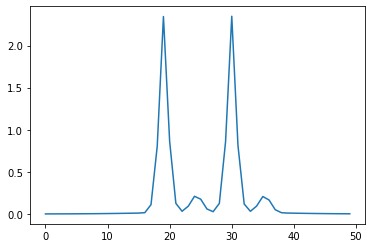

density integral tensor(214.8938, grad_fn=<SumBackward0>)
tensor([[4.2974e+00, 1.7896e+00, 1.6864e-03, 1.9145e+00, 7.3858e-01, 5.5989e+00,
         3.9190e-01, 3.6912e-01, 2.3373e-01, 8.2793e-01, 7.6471e-01, 6.5990e-01,
         4.9925e+00, 4.6081e-01, 1.1735e+01, 1.8860e-01, 6.5908e-01, 4.9948e+00,
         4.5945e-01, 1.1733e+01, 1.8807e-01, 4.3008e+00, 1.7871e+00, 1.6877e-03,
         1.9202e+00, 7.3844e-01, 5.5965e+00, 3.9145e-01, 3.6904e-01, 2.3410e-01,
         8.2945e-01, 7.6561e-01, 6.5590e-01, 5.0032e+00, 4.6122e-01, 1.1740e+01,
         1.8793e-01, 6.5983e-01, 4.9862e+00, 4.5981e-01, 1.1732e+01, 1.8860e-01]],
       grad_fn=<CatBackward0>)
coeffs sum tensor(106.0086, grad_fn=<SumBackward0>)
coeffs sum 1st tensor(52.9995, grad_fn=<SumBackward0>)
coeffs sum 2nd tensor(53.0091, grad_fn=<SumBackward0>)
torch.Size([1, 42])


In [45]:
import matplotlib.pyplot as plt

print(repr['density'].shape)

print(repr['density'][0, 13, 9, 11])

print(repr['density'][0, 36, 9, 11])
plt.plot(repr['density'][0,:,5, 11].detach().cpu().numpy())
plt.show()
print('density integral', torch.sum(repr['density']))
print(repr['L0_coeffs'])
print('coeffs sum', torch.sum(repr['L0_coeffs']))
print('coeffs sum 1st', torch.sum(repr['L0_coeffs'][:, :21]))
print('coeffs sum 2nd', torch.sum(repr['L0_coeffs'][:, 21:]))
print(repr['L0_coeffs'].shape)

In [46]:
# try dimer and architectures
for idx in np.arange(0, 1200, 100):
    print(idx)
    dimer_sample = {}
    result = {}
    dimer_sample['positions'] = torch.Tensor(water_dimer['positions'][[idx]]).to(args.dtype)
    dimer_sample['atom_numbers'] = torch.LongTensor(water_dimer['atom_numbers']).unsqueeze(0)
    dimer_sample['atom_mask'] = dimer_sample['atom_numbers'] != 0
    print(water_dimer['atom_numbers'])
    dimer_sample['coords'] = grid
    dimer_sample['coord_weights'] = grid_weights
    print('positions', dimer_sample['positions'])
    print('positions shape', dimer_sample['positions'].shape)
    print('atom_numbers', dimer_sample['atom_numbers'])
    repr = model(dimer_sample)

    fname = 'datasets/water_dens_dimer/' + str(idx) + '.cube'
    #ase.io.cube.write_cube(f, mol[0], data=repr['density'].detach().cpu().numpy().squeeze())
    print('density shape', repr['density'].detach().cpu().numpy().squeeze().shape)
    #ase.io.cube.write_cube(f, mol[0], data=np.ones((50, 50, 50)))
    #data = np.ones((50, 50, 50))
    meta = {'atoms': []}
    for i in range(dimer_sample['positions'].shape[1]): 
        pos = utils.angstrom_to_bohr(dimer_sample['positions'])
        meta['atoms'].append((dimer_sample['atom_numbers'].squeeze()[i], pos.squeeze()[i].tolist()))
    print('atoms', meta['atoms'])
    min_coords, _ = torch.min(utils.angstrom_to_bohr(dimer_sample['coords'].view(-1, 3)), dim=0)
    max_coords, _ = torch.max(utils.angstrom_to_bohr(dimer_sample['coords'].view(-1, 3)), dim=0)
    print('min coords', min_coords)
    print('max coords', max_coords)
    lattice = (max_coords - min_coords).detach().cpu().numpy()
    print('lattice', lattice)
    step_size = lattice/repr['density'].squeeze().shape
    print('step_size', step_size)
    meta['org'] = min_coords.tolist()
    meta['xvec'] = [step_size[0], 0, 0]
    meta['yvec'] = [0, step_size[1], 0]
    meta['zvec'] = [0, 0, step_size[2]]
    cubetools.write_cube(data=repr['density'].detach().cpu().numpy().squeeze(), meta=meta, fname=fname)

0
[8 1 1 8 1 1]
positions tensor([[[-2.5000,  0.0000,  0.0000],
         [-1.5307, -0.1022,  0.0000],
         [-2.6022,  0.9693,  0.0000],
         [ 2.5000,  0.0000,  0.0000],
         [ 3.4693, -0.1022,  0.0000],
         [ 2.3978,  0.9693,  0.0000]]])
positions shape torch.Size([1, 6, 3])
atom_numbers tensor([[8, 1, 1, 8, 1, 1]])
density shape (50, 17, 22)
atoms [(tensor(8), [-4.724315166473389, 0.0, 0.0]), (tensor(1), [-2.8926455974578857, -0.1932237595319748, 0.0]), (tensor(1), [-4.917538642883301, 1.8316694498062134, 0.0]), (tensor(8), [4.724315166473389, 0.0, 0.0]), (tensor(1), [6.5559844970703125, -0.1932237595319748, 0.0]), (tensor(1), [4.531091213226318, 1.8316694498062134, 0.0])]
min coords tensor([-8.4457, -2.0829, -3.7214])
max coords tensor([8.4457, 3.7214, 3.7214])
lattice [16.891422   5.8043456  7.4427915]
step_size [0.33782845 0.34143209 0.3383087 ]
100
[8 1 1 8 1 1]
positions tensor([[[-2.5000,  0.0000,  0.0000],
         [-2.0665,  0.4335, -0.7577],
         [-2.066

In [52]:
# try water
for idx in np.arange(0, 1200, 100):
    print(idx)
    dimer_sample = {}
    result = {}
    dimer_sample['positions'] = torch.Tensor(water_dimer['positions'][[idx]]).to(args.dtype)
    dimer_sample['atom_numbers'] = torch.LongTensor(water_dimer['atom_numbers']).unsqueeze(0)
    dimer_sample['atom_numbers'][:, :3] = 0 
    dimer_sample['atom_mask'] = dimer_sample['atom_numbers'] != 0
    print(water_dimer['atom_numbers'])
    dimer_sample['coords'] = grid
    dimer_sample['coord_weights'] = grid_weights
    print('positions', dimer_sample['positions'])
    print('positions shape', dimer_sample['positions'].shape)
    print('atom_numbers', dimer_sample['atom_numbers'])
    repr = model(dimer_sample)

    fname = 'datasets/water_dens_mono/' + str(idx) + '.cube'
    #ase.io.cube.write_cube(f, mol[0], data=repr['density'].detach().cpu().numpy().squeeze())
    print('density shape', repr['density'].detach().cpu().numpy().squeeze().shape)
    #ase.io.cube.write_cube(f, mol[0], data=np.ones((50, 50, 50)))
    #data = np.ones((50, 50, 50))
    meta = {'atoms': []}
    for i in range(dimer_sample['positions'].shape[1]): 
        pos = utils.angstrom_to_bohr(dimer_sample['positions'])
        meta['atoms'].append((dimer_sample['atom_numbers'].squeeze()[i], pos.squeeze()[i].tolist()))
    print('atoms', meta['atoms'])
    min_coords, _ = torch.min(utils.angstrom_to_bohr(dimer_sample['coords'].view(-1, 3)), dim=0)
    max_coords, _ = torch.max(utils.angstrom_to_bohr(dimer_sample['coords'].view(-1, 3)), dim=0)
    print('min coords', min_coords)
    print('max coords', max_coords)
    lattice = (max_coords - min_coords).detach().cpu().numpy()
    print('lattice', lattice)
    step_size = lattice/repr['density'].squeeze().shape
    print('step_size', step_size)
    meta['org'] = min_coords.tolist()
    meta['xvec'] = [step_size[0], 0, 0]
    meta['yvec'] = [0, step_size[1], 0]
    meta['zvec'] = [0, 0, step_size[2]]
    cubetools.write_cube(data=repr['density'].detach().cpu().numpy().squeeze(), meta=meta, fname=fname)

0
[0 0 0 8 1 1]
positions tensor([[[-2.5000,  0.0000,  0.0000],
         [-1.5307, -0.1022,  0.0000],
         [-2.6022,  0.9693,  0.0000],
         [ 2.5000,  0.0000,  0.0000],
         [ 3.4693, -0.1022,  0.0000],
         [ 2.3978,  0.9693,  0.0000]]])
positions shape torch.Size([1, 6, 3])
atom_numbers tensor([[0, 0, 0, 8, 1, 1]])
density shape (50, 17, 22)
atoms [(tensor(0), [-4.724315166473389, 0.0, 0.0]), (tensor(0), [-2.8926455974578857, -0.1932237595319748, 0.0]), (tensor(0), [-4.917538642883301, 1.8316694498062134, 0.0]), (tensor(8), [4.724315166473389, 0.0, 0.0]), (tensor(1), [6.5559844970703125, -0.1932237595319748, 0.0]), (tensor(1), [4.531091213226318, 1.8316694498062134, 0.0])]
min coords tensor([-8.4457, -2.0829, -3.7214])
max coords tensor([8.4457, 3.7214, 3.7214])
lattice [16.891422   5.8043456  7.4427915]
step_size [0.33782845 0.34143209 0.3383087 ]
100
[0 0 0 8 1 1]
positions tensor([[[-2.5000,  0.0000,  0.0000],
         [-2.0665,  0.4335, -0.7577],
         [-2.066

In [71]:
idxs = np.arange(0, 1300, 100)
print(idxs)
dimer_sample = {}
result = {}
dimer_sample['positions'] = torch.Tensor(water_dimer['positions'][idxs]).to(args.dtype)
batch_size = dimer_sample['positions'].shape[0]
dimer_sample['atom_numbers'] = torch.LongTensor(water_dimer['atom_numbers']).unsqueeze(0).repeat(batch_size, 1)
dimer_sample['atom_numbers'][2, :3] = 0
dimer_sample['atom_numbers'][5, 3:] = 0
dimer_sample['atom_numbers'][8, :3] = 0
dimer_sample['atom_numbers'][10, :3] = 0
dimer_sample['atom_mask'] = dimer_sample['atom_numbers'] != 0
print(water_dimer['atom_numbers'])
dimer_sample['coords'] = grid.repeat((batch_size,) + (1,) * (grid.dim()-1))
dimer_sample['coord_weights'] = grid_weights.repeat((batch_size,) + (1,) * (grid_weights.dim()-1))
print('positions', dimer_sample['positions'])
print('positions shape', dimer_sample['positions'].shape)
print('atom_numbers', dimer_sample['atom_numbers'])
repr = model(dimer_sample)

#ase.io.cube.write_cube(f, mol[0], data=repr['density'].detach().cpu().numpy().squeeze())
print('density shape', repr['density'].detach().cpu().numpy().squeeze().shape)
#ase.io.cube.write_cube(f, mol[0], data=np.ones((50, 50, 50)))
#data = np.ones((50, 50, 50))
for j in range(batch_size):
    fname = 'datasets/water_dens_mixed/' + str(idxs[j]) + '.cube'
    meta = {'atoms': []}
    for i in range(dimer_sample['positions'].shape[1]): 
        pos = utils.angstrom_to_bohr(dimer_sample['positions'])
        meta['atoms'].append((dimer_sample['atom_numbers'].squeeze()[j, i], pos.squeeze()[j, i].tolist()))
    print('atoms', meta['atoms'])
    min_coords, _ = torch.min(utils.angstrom_to_bohr(dimer_sample['coords'].view(-1, 3)), dim=0)
    max_coords, _ = torch.max(utils.angstrom_to_bohr(dimer_sample['coords'].view(-1, 3)), dim=0)
    print('min coords', min_coords)
    print('max coords', max_coords)
    lattice = (max_coords - min_coords).detach().cpu().numpy()
    print('lattice', lattice)
    step_size = lattice/repr['density'][j].shape
    print('step_size', step_size)
    meta['org'] = min_coords.tolist()
    meta['xvec'] = [step_size[0], 0, 0]
    meta['yvec'] = [0, step_size[1], 0]
    meta['zvec'] = [0, 0, step_size[2]]
    cubetools.write_cube(data=repr['density'][j].detach().cpu().numpy().squeeze(), meta=meta, fname=fname)

[   0  100  200  300  400  500  600  700  800  900 1000 1100 1200]
[8 1 1 8 1 1]
positions tensor([[[-2.5000e+00,  0.0000e+00,  0.0000e+00],
         [-1.5307e+00, -1.0225e-01,  0.0000e+00],
         [-2.6022e+00,  9.6928e-01,  0.0000e+00],
         [ 2.5000e+00,  0.0000e+00,  0.0000e+00],
         [ 3.4693e+00, -1.0225e-01,  0.0000e+00],
         [ 2.3978e+00,  9.6928e-01,  0.0000e+00]],

        [[-2.5000e+00,  0.0000e+00,  0.0000e+00],
         [-2.0665e+00,  4.3351e-01, -7.5768e-01],
         [-2.0665e+00,  4.3351e-01,  7.5768e-01],
         [ 2.5000e+00,  0.0000e+00,  0.0000e+00],
         [ 3.1854e+00, -1.0225e-01, -6.8538e-01],
         [ 2.4277e+00,  9.6928e-01,  7.2301e-02]],

        [[-2.5000e+00,  0.0000e+00,  0.0000e+00],
         [-2.5000e+00, -1.0225e-01, -9.6928e-01],
         [-2.5000e+00,  9.6928e-01,  1.0225e-01],
         [ 2.5000e+00,  0.0000e+00,  0.0000e+00],
         [ 3.4693e+00,  0.0000e+00, -1.0225e-01],
         [ 2.3978e+00,  1.0000e-16,  9.6928e-01]],

   

In [4]:
        
    """
    Write volumetric data to cube file along
    params:
        data: volumetric data consisting real values
        meta: dict containing metadata with following keys
            atoms: list of atoms in the form (mass, [position])
            org: origin
            xvec,yvec,zvec: lattice vector basis
        fname: filename of cubefile (existing files overwritten)

    returns: None
    """

IndentationError: expected an indented block (<ipython-input-4-ae592d2d0e9b>, line 34)

NameError: name 'JsmolView' is not defined

JsmolView(layout=Layout(align_self='stretch', height='400px'))


In [ ]:
from schnetpack.md.utils import HDF5Loader
import numpy as np
import sys
import ase.io
import equiv_dens.utils.base as utils

file = sys.argv[1]

data = data = HDF5Loader(file, load_properties=False)
positions = data.properties['_positions'].squeeze(1) * 10
atom_numbers = data.properties['_atomic_numbers']
print('positions.shape', positions.shape)
print('atom_numbers.shape', atom_numbers.shape)
for i in range(positions.shape[1]):
    pos = positions[:, i]
    mols = utils.npy_to_ase(pos, atom_numbers[0])
    ase.io.write(file[:-5] + '_' + str(i) + '.xyz', mols)
    print('positions', i , pos)

